# Exercise Counterfactual: What Would Glucose Have Done If This Person Had Exercised?

Successor to the meal counterfactual (Study 1, not constructible in AI-READI).

**Scope:** Primary analysis on NON-INSULIN participants only (normoglycemia, prediabetes, T2D-oral).  
T2D-insulin participants have unobserved dosing that makes counterfactual glucose claims uninterpretable.  
Insulin group appears in a descriptive-only appendix, clearly labeled.

**Method:** SSM-CGM conditioning approach. Same history, intervened future covariates, single forward pass.  
Frozen base checkpoint only. No retraining.

**Parts:**
- A: Define the exercise covariate template (empirical, from real episodes)
- B: Build the counterfactual (impose exercise on non-exercise moments)
- C: Plausibility check vs descriptive glucose kernel
- D: Natural-experiment validation with matched pairs
- E: Bias correction using Stage 2 diagnostic
- F: Sensitivity analysis on unmeasured confounding
- G: Verdict and scoping

In [1]:
from __future__ import annotations
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import torch

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)

def find_project_root() -> Path:
    for start in [Path.cwd(), Path.cwd().parent, Path('/home/myriamcharfeddine/CGM/SSM-CGM')]:
        if (start / 'ssmcgm').is_dir():
            return start
    raise RuntimeError('Cannot find project root with ssmcgm/ package.')

ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

mpl.rcParams.update({
    'font.size': 8, 'axes.labelsize': 8, 'xtick.labelsize': 7, 'ytick.labelsize': 7,
    'legend.fontsize': 7, 'lines.linewidth': 1.2, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True, 'grid.linestyle': '--',
    'grid.alpha': 0.3, 'pdf.fonttype': 42,
})

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Root: {ROOT}')
print(f'Device: {DEVICE}')

Root: /home/myriamcharfeddine/CGM/SSM-CGM
Device: cuda


## 0. Paths and Configuration

In [2]:
# ---- artifact paths ----
CKPT_PATH        = ROOT / 'outputs/aireadi_stream_mamba_stateful_5epoch/checkpoints/best_model_checkpoint.pt'
SCHEMA_PATH      = ROOT / 'outputs/aireadi_stream_mamba_stateful_5epoch/schema_mapping.json'
VERDICT_PATH     = ROOT / 'outputs/stage2_residual_diagnostic/diagnostic_verdict.json'
RESIDUAL_TRAJ    = ROOT / 'outputs/stage2_residual_diagnostic/residual_trajectory_summary.csv'
EPISODE_PATH     = ROOT / 'notebooks/outputs/exercise_episode_detection_v2/exercise_episodes_features.parquet'
COHORT_PATH      = ROOT.parent / 'Data/enriched_multimodal/cohort.csv'
PANEL_PATH       = ROOT.parent / 'Data/enriched_multimodal/final_multimodal_dataset_20260515_184339.parquet'
STATIC_PATH      = ROOT.parent / 'Data/enriched_multimodal/participant_static_features.parquet'
SPLIT_PATH       = ROOT.parent / 'Data/experiment_c_split_adapt6h_seed42/split_participants.csv'
UNCERTAIN_AROUSAL_PATH = ROOT / 'notebooks/outputs/exercise_episode_detection_v2/uncertain_arousal_intervals.parquet'

OUT_DIR = ROOT / 'outputs/exercise_counterfactual'
OUT_DIR.mkdir(parents=True, exist_ok=True)

for p in [CKPT_PATH, EPISODE_PATH, COHORT_PATH, PANEL_PATH, VERDICT_PATH]:
    status = 'OK' if p.exists() else 'MISSING'
    print(f'  {status}: {p.name}')

# ---- operational knobs ----
SMOKE            = False          # set True to test on 10 participants
HORIZON_STEPS    = 12             # 12 x 5min = 60min
BIN_MINUTES      = 5
# Stride for non-exercise anchors (every 15 min to keep compute tractable)
ANCHOR_STRIDE    = 3              # in steps of 5 min
# For Part B, use validation + test splits (out-of-sample, no data leakage)
EVAL_SPLITS      = ('validation', 'test')
HIGH_CONF_CLASSES = ('high',)     # episode_confidence_class filter
EXERCISE_EXCLUSION_PAD_MIN = 30   # minutes around exercise to exclude from anchors
# Rest-entry criterion
REST_MAX_HR_EXCESS   = 5.0        # bpm above baseline to consider 'at rest'
REST_MAX_STEPS_RATE  = 2.0        # steps/min to consider 'at rest'
NON_INSULIN_STRATA   = frozenset(['normoglycemia', 'prediabetes', 'T2D-oral'])
INSULIN_STRATA       = frozenset(['T2D-insulin'])
PRIMARY_STRAINS      = ('moderate', 'vigorous')

print('\nConfiguration OK')

  OK: best_model_checkpoint.pt
  OK: exercise_episodes_features.parquet
  OK: cohort.csv
  OK: final_multimodal_dataset_20260515_184339.parquet
  OK: diagnostic_verdict.json

Configuration OK


## 1. Load Artifacts

In [3]:
from ssmcgm.models.aireadi_stream import AireadiStreamModel, AireadiStreamModelConfig
from ssmcgm.data.aireadi import (
    AireadiFeatureSpec, AireadiPreprocessor,
    build_stream_feature_spec, infer_or_validate_schema,
    load_aireadi_panel, make_aireadi_stream_splits,
    make_participant_streams, prepare_aireadi_panel,
)

# ---- Load frozen checkpoint ----
ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
md = ckpt['metadata']
SPEC = AireadiFeatureSpec(**md['feature_spec'])
PREP = AireadiPreprocessor.from_jsonable(md['preprocessor'])
MCFG = AireadiStreamModelConfig(**md['model_config'])
MODEL = AireadiStreamModel(SPEC, PREP, MCFG)
MODEL.load_state_dict(ckpt['model_state_dict'])
MODEL.eval()
for p in MODEL.parameters():
    p.requires_grad_(False)
MODEL = MODEL.to(DEVICE)
print('Model loaded. Parameters:', sum(p.numel() for p in MODEL.parameters()))
print('Scenario variables:', SPEC.scenario_reals)

# ---- Scenario indices ----
SCN_VARS = SPEC.scenario_reals
ACTIVITY_PROXY = SPEC.scenario_groups.get('activity_proxy', [])
print('Activity proxy vars:', ACTIVITY_PROXY)

/home/myriamcharfeddine/miniconda3/envs/ssmcgm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model loaded. Parameters: 558898
Scenario variables: ['predmeal_flag', 'heart_rate_mean', 'activity_steps_per_min', 'stress_level_mean', 'sleep_stage_awake', 'sleep_stage_light', 'sleep_stage_deep', 'sleep_stage_rem', 'activity_stage_sedentary']
Activity proxy vars: ['heart_rate_mean', 'activity_steps_per_min', 'stress_level_mean']


In [4]:
# ---- Normalization stats for scenario variables ----
with open(ROOT / 'outputs/aireadi_stream_mamba_stateful_5epoch/preprocessor.json') as f:
    prep_json = json.load(f)
CONT_STATS = prep_json['continuous_stats']

def normalize(var: str, raw_value: float) -> float:
    s = CONT_STATS.get(var, {'mean': 0.0, 'std': 1.0})
    return (raw_value - s['mean']) / max(s['std'], 1e-8)

def normalize_array(var: str, arr: np.ndarray) -> np.ndarray:
    s = CONT_STATS.get(var, {'mean': 0.0, 'std': 1.0})
    return (arr - s['mean']) / max(s['std'], 1e-8)

print('Stats for activity proxy vars:')
for v in ACTIVITY_PROXY:
    print(f'  {v}: mean={CONT_STATS[v]["mean"]:.3f}, std={CONT_STATS[v]["std"]:.3f}')

Stats for activity proxy vars:
  heart_rate_mean: mean=75.186, std=14.828
  activity_steps_per_min: mean=6.747, std=14.450
  stress_level_mean: mean=52.158, std=26.723


In [5]:
# ---- Cohort: identify non-insulin participants ----
cohort = pd.read_csv(COHORT_PATH)
cohort['participant_id'] = cohort['participant_id'].astype(str)
non_insulin_pids = set(cohort[cohort['stratum'].isin(NON_INSULIN_STRATA)]['participant_id'])
insulin_pids     = set(cohort[cohort['stratum'].isin(INSULIN_STRATA)]['participant_id'])
print(f'Non-insulin participants: {len(non_insulin_pids)}')
print(f'Insulin (appendix only): {len(insulin_pids)}')
print(cohort[cohort['stratum'].isin(NON_INSULIN_STRATA | INSULIN_STRATA)]['stratum'].value_counts())

Non-insulin participants: 1427
Insulin (appendix only): 164
stratum
normoglycemia    564
T2D-oral         458
prediabetes      405
T2D-insulin      164
Name: count, dtype: int64


In [6]:
# ---- Exercise episodes ----
episodes_all = pd.read_parquet(EPISODE_PATH).copy()
episodes_all['participant_id'] = episodes_all['participant_id'].astype(str)
for tc in ['refined_start_time', 'refined_end_time', 'start_time', 'end_time']:
    if tc in episodes_all.columns:
        episodes_all[tc] = pd.to_datetime(episodes_all[tc])

episodes_ni = episodes_all[episodes_all['participant_id'].isin(non_insulin_pids)].copy()
ep_hi_ni = episodes_ni[episodes_ni['episode_confidence_class'].isin(HIGH_CONF_CLASSES)]
print(f'All episodes non-insulin: {len(episodes_ni)}')
print(f'High-confidence non-insulin: {len(ep_hi_ni)}')
print(ep_hi_ni['strain_class'].value_counts())

All episodes non-insulin: 2807
High-confidence non-insulin: 2039
strain_class
vigorous         1006
moderate          935
light              86
sub_threshold      12
Name: count, dtype: int64


In [7]:
# ---- Stage 2 diagnostic verdict (bias values for correction) ----
verdict = json.loads(VERDICT_PATH.read_text())
residual_traj = pd.read_csv(RESIDUAL_TRAJ)

# Build per-strain, per-horizon bias lookup
# episode_residual = predicted - actual during exercise = positive bias = model over-predicts
# This means the model under-predicts the glucose DROP
# bias_by_strain[strain][horizon_step] = bias in mg/dL
bias_by_strain = {}
for strain in ['moderate', 'vigorous', 'all']:
    rows = residual_traj[residual_traj['strain_class'] == strain].sort_values('horizon_step')
    bias_by_strain[strain] = dict(zip(rows['horizon_step'], rows['episode_residual']))

print('Bias at 60min (horizon_step=12):')
for s in ['moderate', 'vigorous']:
    print(f'  {s}: {bias_by_strain[s].get(12, float("nan")):.2f} mg/dL')
print('Verdict decision:', verdict['decision'])

Bias at 60min (horizon_step=12):
  moderate: 4.81 mg/dL
  vigorous: 7.17 mg/dL
Verdict decision: JUSTIFIED


## Part A: Define the Intervention (Exercise Covariate Template)

Build the empirical exercise covariate template from high-confidence non-insulin episodes.
Template = mean trajectory of activity_proxy scenario variables aligned at refined_start_time,
from onset to 60 minutes, per strain_class (moderate, vigorous).

In [8]:
# Load panel for template-building participants (only the columns we need)
import pyarrow.parquet as pq

template_pids = sorted(ep_hi_ni['participant_id'].unique())
print(f'Participants with high-confidence episodes: {len(template_pids)}')

PANEL_COLS = ['participant_id', 'timestamp_local', 'heart_rate_mean',
              'activity_steps_per_min', 'stress_level_mean',
              'sleep_stage_awake', 'activity_stage_sedentary',
              'activity_stage_walking', 'activity_stage_running',
              'cgm_glucose_mean']

panel_templ = pq.read_table(
    PANEL_PATH,
    columns=PANEL_COLS,
    filters=[('participant_id', 'in', template_pids)]
).to_pandas()
panel_templ['participant_id'] = panel_templ['participant_id'].astype(str)
panel_templ['timestamp_local'] = pd.to_datetime(panel_templ['timestamp_local'])
print(f'Panel rows for template participants: {len(panel_templ):,}')

Participants with high-confidence episodes: 704
Panel rows for template participants: 1,800,485


In [9]:
# For each high-confidence episode, extract 60-minute window aligned at refined_start_time
TEMPLATE_VARS = ACTIVITY_PROXY  # ['heart_rate_mean', 'activity_steps_per_min', 'stress_level_mean']
HORIZON_MIN   = 60
STEP_MIN      = BIN_MINUTES
NSTEPS        = HORIZON_MIN // STEP_MIN  # = 12

# Build per-pid panel index
panel_by_pid = {}
for pid, grp in panel_templ.groupby('participant_id', sort=False):
    grp = grp.sort_values('timestamp_local').copy()
    grp['ts_ns'] = grp['timestamp_local'].astype('int64')
    panel_by_pid[pid] = grp

def extract_template_window(pid: str, onset_ts, n_steps: int, var: str) -> np.ndarray | None:
    """Extract n_steps of var starting at onset_ts (5-min bins). Returns NaN-filled array if sparse."""
    grp = panel_by_pid.get(pid)
    if grp is None:
        return None
    onset_dt = pd.to_datetime(onset_ts)
    end_dt = onset_dt + pd.Timedelta(minutes=n_steps * STEP_MIN)
    mask = (grp['timestamp_local'] >= onset_dt) & (grp['timestamp_local'] < end_dt)
    sub = grp[mask].copy()
    if len(sub) == 0:
        return None
    # Snap to regular 5-min grid
    sub['step'] = ((sub['timestamp_local'] - onset_dt).dt.total_seconds() / (STEP_MIN * 60)).round().astype(int)
    sub = sub[sub['step'].between(0, n_steps - 1)].drop_duplicates('step')
    out = np.full(n_steps, np.nan)
    if var in sub.columns:
        for _, row in sub.iterrows():
            out[int(row['step'])] = float(row[var]) if pd.notna(row[var]) else np.nan
    # Require at least 50% coverage
    if np.isfinite(out).mean() < 0.5:
        return None
    return out

# Build template: collect all episodes per strain, per variable
template_raw = {s: {v: [] for v in TEMPLATE_VARS} for s in ['moderate', 'vigorous', 'light']}

for _, ep_row in ep_hi_ni.iterrows():
    strain = ep_row['strain_class']
    if strain not in template_raw:
        continue
    pid = str(ep_row['participant_id'])
    onset = ep_row['refined_start_time']
    for var in TEMPLATE_VARS:
        w = extract_template_window(pid, onset, NSTEPS, var)
        if w is not None:
            template_raw[strain][var].append(w)

# Average template per strain per variable
templates = {}
for strain, var_dict in template_raw.items():
    templates[strain] = {}
    for var, windows in var_dict.items():
        if windows:
            mat = np.array(windows)  # (N_episodes, 12)
            templates[strain][var] = np.nanmean(mat, axis=0)
        else:
            templates[strain][var] = np.zeros(NSTEPS)
    print(f'  {strain}: {len(var_dict[TEMPLATE_VARS[0]])} episodes with HR coverage')

print('\nTemplate (moderate, mean HR trajectory):', np.round(templates['moderate']['heart_rate_mean'], 1))

  moderate: 935 episodes with HR coverage
  vigorous: 1006 episodes with HR coverage
  light: 86 episodes with HR coverage

Template (moderate, mean HR trajectory): [102.8 103.7 104.  104.  104.2 104.  104.1 103.7 103.4 102.8 101.7 101.3]


In [10]:
# Normalize templates to z-scores (model input space)
templates_z = {}
for strain, var_dict in templates.items():
    templates_z[strain] = {var: normalize_array(var, arr) for var, arr in var_dict.items()}

# Build tensors for the two primary strains (shape: [HORIZON_STEPS, n_activity_vars])
SCN_IDX = {var: SCN_VARS.index(var) for var in ACTIVITY_PROXY if var in SCN_VARS}
print('Scenario indices for activity proxy:', SCN_IDX)

exercise_templates = {}
for strain in PRIMARY_STRAINS:
    t = templates_z[strain]
    # Shape: [HORIZON_STEPS, n_scenario_vars] - fill with zeros, then set activity vars
    tmpl = np.zeros((HORIZON_STEPS, len(SCN_VARS)), dtype=np.float32)
    for var, idx in SCN_IDX.items():
        tmpl[:, idx] = t[var].astype(np.float32)
    exercise_templates[strain] = torch.tensor(tmpl, dtype=torch.float32)
    print(f'{strain} template shape: {exercise_templates[strain].shape}')

Scenario indices for activity proxy: {'heart_rate_mean': 1, 'activity_steps_per_min': 2, 'stress_level_mean': 3}
moderate template shape: torch.Size([12, 9])
vigorous template shape: torch.Size([12, 9])


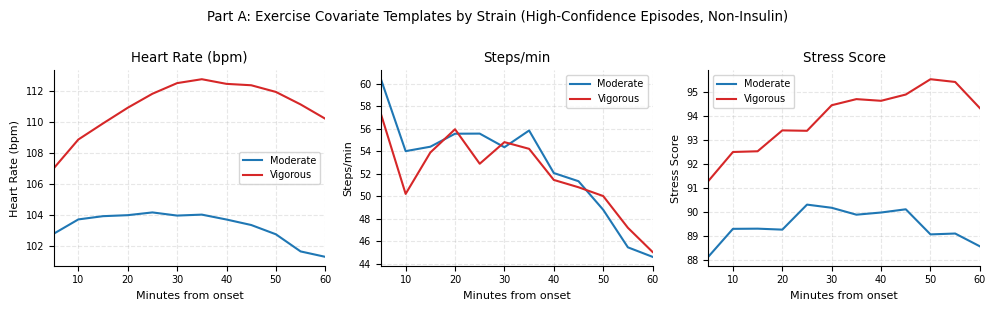

Saved fig_A_exercise_templates.png


In [11]:
# Figure: Exercise covariate templates by strain
fig, axes = plt.subplots(1, len(TEMPLATE_VARS), figsize=(10, 3), sharey=False)
steps_min = np.arange(STEP_MIN, (NSTEPS + 1) * STEP_MIN, STEP_MIN)

strain_colors = {'moderate': '#1f77b4', 'vigorous': '#d62728', 'light': '#9467bd'}
strain_labels = {'moderate': 'Moderate', 'vigorous': 'Vigorous', 'light': 'Light'}

var_labels = {
    'heart_rate_mean': 'Heart Rate (bpm)',
    'activity_steps_per_min': 'Steps/min',
    'stress_level_mean': 'Stress Score',
}

for ax, var in zip(axes, TEMPLATE_VARS):
    for strain in ['moderate', 'vigorous']:
        tmpl = templates[strain].get(var)
        if tmpl is not None:
            ax.plot(steps_min, tmpl, label=strain_labels[strain], color=strain_colors[strain], lw=1.5)
    ax.set_xlabel('Minutes from onset')
    ax.set_ylabel(var_labels.get(var, var))
    ax.legend(fontsize=7)
    ax.set_title(f'{var_labels.get(var, var)}')
    ax.set_xlim(steps_min[0], steps_min[-1])

fig.suptitle('Part A: Exercise Covariate Templates by Strain (High-Confidence Episodes, Non-Insulin)', y=1.01)
plt.tight_layout()
fig.savefig(OUT_DIR / 'fig_A_exercise_templates.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_A_exercise_templates.png')

## Part B: Build the Counterfactual

1. Identify non-exercise anchor moments in non-insulin participants
2. For each anchor: factual forecast (no exercise) vs counterfactual forecast (exercise template)
3. delta_cf(t) = counterfactual_glucose(t) - factual_glucose(t)

In [12]:
# Load and prepare panel for eval splits (non-insulin participants)
split_df = pd.read_csv(SPLIT_PATH)
split_df['participant_id'] = split_df['participant_id'].astype(str)
eval_pids = set(
    split_df[
        split_df['split'].isin(EVAL_SPLITS)
        & split_df['participant_id'].isin(non_insulin_pids)
    ]['participant_id']
)
if SMOKE:
    eval_pids = set(sorted(eval_pids)[:10])
print(f'Eval participants (non-insulin, {EVAL_SPLITS}): {len(eval_pids)}')

print('Loading panel (filtering to eval_pids after load)...')
# load_aireadi_panel's smoke_participants takes first N sorted pids -- not what we want.
# Load the full cohort-filtered panel and then filter to eval_pids explicitly.
panel_df = load_aireadi_panel(
    str(PANEL_PATH),
    cohort_path=str(COHORT_PATH),
)
panel_df['participant_id'] = panel_df['participant_id'].astype(str)
panel_df = panel_df[panel_df['participant_id'].isin(eval_pids)].copy()
print(f'Panel rows for eval participants: {len(panel_df):,}')

Eval participants (non-insulin, ('validation', 'test')): 198
Loading panel (filtering to eval_pids after load)...


Panel rows for eval participants: 502,455


In [13]:
# Prepare panel (segment ID, time_idx, normalization)
schema = infer_or_validate_schema(panel_df)
panel_df = prepare_aireadi_panel(
    panel_df, schema,
    bin_minutes=BIN_MINUTES,
    clean_min_segment_hours=49,
)
print(f'Panel after prepare: {len(panel_df):,} rows')
print(f'Unique participants: {panel_df["participant_id"].nunique()}')

Panel after prepare: 421,127 rows
Unique participants: 198


In [14]:
# Build participant streams (eval splits only)
split_obj = make_aireadi_stream_splits(
    panel_df,
    split_mode='participant_heldout',
    existing_split_path=str(SPLIT_PATH),
)
streams = make_participant_streams(
    panel_df, split_obj, schema,
    feature_spec=SPEC,
    preprocessor=PREP,
    splits=list(EVAL_SPLITS),
    min_steps=SPEC.horizon_steps + 2,
)
print(f'Streams built: {len(streams)}')

Streams built: 343


In [15]:
# Build exercise exclusion lookup: for each participant, list of (exclude_start, exclude_end) windows
# Exclude: any bin within EXERCISE_EXCLUSION_PAD_MIN of a detected exercise episode
excl_pad = pd.Timedelta(minutes=EXERCISE_EXCLUSION_PAD_MIN)

exclude_intervals = {}  # pid -> list of (start_ns, end_ns)
for pid, grp in episodes_all[episodes_all['participant_id'].isin(eval_pids)].groupby('participant_id'):
    excl = []
    for _, row in grp.iterrows():
        st = pd.to_datetime(row['refined_start_time']) - excl_pad
        en = pd.to_datetime(row['refined_end_time']) + excl_pad
        excl.append((st.value, en.value))
    exclude_intervals[str(pid)] = excl

# Also exclude uncertain arousal intervals if available
if UNCERTAIN_AROUSAL_PATH.exists():
    arousal = pd.read_parquet(UNCERTAIN_AROUSAL_PATH)
    arousal['participant_id'] = arousal['participant_id'].astype(str)
    for tc in ['start_time', 'end_time']:
        if tc in arousal.columns:
            arousal[tc] = pd.to_datetime(arousal[tc])
    for pid, grp in arousal[arousal['participant_id'].isin(eval_pids)].groupby('participant_id'):
        excl = exclude_intervals.get(str(pid), [])
        for _, row in grp.iterrows():
            st = pd.to_datetime(row.get('start_time', row.get('refined_start_time', None)))
            en = pd.to_datetime(row.get('end_time', row.get('refined_end_time', None)))
            if pd.notna(st) and pd.notna(en):
                excl.append((st.value, en.value))
        exclude_intervals[str(pid)] = excl
    print(f'Loaded uncertain arousal intervals: {len(arousal)} rows')
else:
    print('No uncertain arousal file found; using exercise exclusion only.')

print(f'Participants with exclusion intervals: {len(exclude_intervals)}')

Loaded uncertain arousal intervals: 35313 rows
Participants with exclusion intervals: 198


In [16]:
import bisect

def is_excluded(ts_ns: int, excl_list: list) -> bool:
    """Check if a nanosecond timestamp falls within any exclusion interval."""
    for st, en in excl_list:
        if st <= ts_ns <= en:
            return True
    return False

def find_non_exercise_anchors(
    stream,
    excl_list: list,
    stride: int,
    horizon: int,
    min_hr_excess_idx: int | None = None,
    hr_excess_thresh: float = REST_MAX_HR_EXCESS,
) -> list:
    """
    Return positions (time indices within segment) that are:
    - Valid (target observed)
    - Not near any exercise episode
    - Awake (sleep_stage_awake feature ~ 1.0 in raw space)
    - At rest going in (HR excess low in raw space)
    - Strided at stride steps
    """
    H = horizon
    anchors = []
    last = -10 ** 9
    n = stream.n_steps
    timestamps = stream.timestamps  # numpy array of datetime64 or tz-aware timestamps

    # Get dynamic var indices for awake check
    dyn_vars = SPEC.dynamic_reals
    awake_idx  = dyn_vars.index('sleep_stage_awake') if 'sleep_stage_awake' in dyn_vars else None
    hr_idx     = dyn_vars.index('heart_rate_mean') if 'heart_rate_mean' in dyn_vars else None
    steps_idx  = dyn_vars.index('activity_steps_per_min') if 'activity_steps_per_min' in dyn_vars else None

    for t in range(0, n - H - 1):
        if (t - last) < stride:
            continue
        if not bool(stream.observed[t]):
            continue
        if not bool(stream.observed[t + 1: t + 1 + H].all()):
            continue

        # Timestamp check
        try:
            ts = pd.Timestamp(timestamps[t])
            ts_ns = ts.value
        except Exception:
            continue

        if is_excluded(ts_ns, excl_list):
            continue

        # Awake check (raw value > 0 means some awake fraction in this 5-min bin)
        # The awake variable in dynamic_reals is z-scored; 0 raw maps to ~-0.3 z-scored
        # We just check that the person is likely awake (not deeply asleep)
        # Use a lenient check: not in deep/REM sleep
        if awake_idx is not None:
            awake_z = float(stream.dynamic[t, awake_idx])
            awake_raw = awake_z * CONT_STATS['sleep_stage_awake']['std'] + CONT_STATS['sleep_stage_awake']['mean']
            if awake_raw < 0.3:  # less than 30% awake fraction -> skip (likely sleeping)
                continue

        # Rest check: low HR and low steps at entry
        if hr_idx is not None:
            hr_z = float(stream.dynamic[t, hr_idx])
            hr_raw = hr_z * CONT_STATS['heart_rate_mean']['std'] + CONT_STATS['heart_rate_mean']['mean']
            if hr_raw > (CONT_STATS['heart_rate_mean']['mean'] + hr_excess_thresh):
                continue

        anchors.append(t)
        last = t

    return anchors

print('Anchor finder ready.')

Anchor finder ready.


In [17]:
# Run counterfactual forward passes
# For each participant stream:
#   1. scan_chunk -> get hidden states at all positions
#   2. Identify non-exercise anchor positions
#   3. Batch decode: factual (all masks=0) and counterfactual (exercise template, masks=1)
#   4. delta_cf = cf_pred - factual_pred

cf_rows = []  # per anchor, per horizon
n_streams_processed = 0
n_anchors_total = 0

# Use moderate as default strain for anchors (we simulate both; moderate is the baseline)
# We will generate one row per (anchor, horizon, strain) for the two primary strains

device_obj = torch.device(DEVICE)
MODEL.to(device_obj)

for stream in streams:
    pid = stream.participant_id
    excl = exclude_intervals.get(pid, [])
    anchors = find_non_exercise_anchors(stream, excl, ANCHOR_STRIDE, HORIZON_STEPS)
    if not anchors:
        continue

    st = stream.to(device_obj)
    sctx = MODEL.encode_static(st.static_cat, st.static_cont)
    _, out = MODEL.scan_chunk(st.dynamic, sctx, MODEL.init_stream(sctx))
    # out: (1, T, hidden_size)

    pos = torch.tensor(anchors, dtype=torch.long, device=device_obj)  # (A,)
    # Future step indices: (A, H)
    fut = pos[:, None] + 1 + torch.arange(HORIZON_STEPS, device=device_obj)[None, :]
    h_anchors = out[0, pos]  # (A, hidden_size)

    # Future time features
    time_fut = st.time_features[fut]  # (A, H, n_time)

    # ---- Factual: all scenario masks 0 (forecast-only) ----
    scn_vals_factual = st.scenario_values[fut]  # (A, H, n_scn)
    scn_mask_factual = torch.zeros_like(scn_vals_factual)  # all masks 0

    raw_factual = MODEL.decode_horizon(h_anchors, sctx, time_fut, scn_vals_factual, scn_mask_factual)
    # raw_factual: (A, H, n_quantiles) - these are residuals from current glucose
    pred_factual = st.target[pos].view(-1, 1, 1) + raw_factual  # absolute glucose
    pred_factual_median = pred_factual[:, :, 1].cpu().numpy()  # (A, H)

    for strain in PRIMARY_STRAINS:
        # ---- Counterfactual: replace activity_proxy with exercise template ----
        tmpl = exercise_templates[strain].to(device_obj)  # (H, n_scn)
        # Build counterfactual scenario: exercise template for activity_proxy, masks=1 for those vars
        scn_vals_cf = scn_vals_factual.clone()  # (A, H, n_scn)
        scn_mask_cf  = scn_mask_factual.clone()
        for var, idx in SCN_IDX.items():
            scn_vals_cf[:, :, idx] = tmpl[None, :, idx]   # broadcast over anchors
            scn_mask_cf[:, :, idx] = 1.0                   # mask on: exercising

        raw_cf = MODEL.decode_horizon(h_anchors, sctx, time_fut, scn_vals_cf, scn_mask_cf)
        pred_cf_median = (st.target[pos].view(-1, 1, 1) + raw_cf)[:, :, 1].cpu().numpy()  # (A, H)

        delta_cf = pred_cf_median - pred_factual_median  # (A, H)

        for ai, anc in enumerate(anchors):
            base_glucose = float(st.target[anc].cpu())
            for h in range(HORIZON_STEPS):
                cf_rows.append({
                    'participant_id': pid,
                    'segment_id': stream.segment_id,
                    'anchor_step': int(anc),
                    'strain': strain,
                    'horizon_step': h + 1,
                    'horizon_minutes': BIN_MINUTES * (h + 1),
                    'pred_factual': float(pred_factual_median[ai, h]),
                    'pred_cf': float(pred_cf_median[ai, h]),
                    'delta_cf': float(delta_cf[ai, h]),
                    'base_glucose': base_glucose,
                    'split': stream.split,
                })

    n_anchors_total += len(anchors)
    n_streams_processed += 1
    if n_streams_processed % 20 == 0:
        print(f'  {n_streams_processed}/{len(streams)} streams | {n_anchors_total} anchors so far')

cf_df = pd.DataFrame(cf_rows)
print(f'\nTotal anchors: {n_anchors_total}')
print(f'Counterfactual rows: {len(cf_df)}')
if len(cf_df):
    print(cf_df.groupby('strain')['anchor_step'].count())

# Save
if len(cf_df):
    cf_df.to_parquet(OUT_DIR / 'counterfactual_effects.parquet', index=False)
    print('Saved counterfactual_effects.parquet')

  20/343 streams | 628 anchors so far
  40/343 streams | 1077 anchors so far
  60/343 streams | 1650 anchors so far
  80/343 streams | 2247 anchors so far
  100/343 streams | 3137 anchors so far
  120/343 streams | 3802 anchors so far
  140/343 streams | 4597 anchors so far
  160/343 streams | 5390 anchors so far
  180/343 streams | 6132 anchors so far
  200/343 streams | 6989 anchors so far
  220/343 streams | 7594 anchors so far
  240/343 streams | 8302 anchors so far
  260/343 streams | 8884 anchors so far
  280/343 streams | 9313 anchors so far
  300/343 streams | 9880 anchors so far
  320/343 streams | 10425 anchors so far

Total anchors: 10755
Counterfactual rows: 258120
strain
moderate    129060
vigorous    129060
Name: anchor_step, dtype: int64
Saved counterfactual_effects.parquet


In [18]:
# Aggregate mean counterfactual effect curve per strain
# Initialize defaults so Part G has variables even if cf_df is empty
plausible_flags = {s: False for s in PRIMARY_STRAINS}
validation_results = {}
sensitivity_results = {}
cf_agg = pd.DataFrame()
cf_corrected = pd.DataFrame()
matched_df = pd.DataFrame()

if len(cf_df) == 0:
    print('WARNING: No counterfactual rows computed. Check anchor finding logic or stream timestamps.')
else:
    cf_agg = (
        cf_df.groupby(['strain', 'horizon_step', 'horizon_minutes'])['delta_cf']
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )
    cf_agg['se'] = cf_agg['std'] / np.sqrt(cf_agg['count'])
    cf_agg['ci95_lo'] = cf_agg['mean'] - 1.96 * cf_agg['se']
    cf_agg['ci95_hi'] = cf_agg['mean'] + 1.96 * cf_agg['se']
    print('Mean counterfactual effect (delta_cf in mg/dL):')
    for strain in PRIMARY_STRAINS:
        s = cf_agg[cf_agg['strain'] == strain]
        rows = s[s['horizon_step'] == 12]
        if len(rows):
            print(f'  {strain} @ 60min: {rows["mean"].values[0]:.2f} mg/dL')
# Degenerate check: is the raw counterfactual near-zero across all strains?
CF_DEGENERACY_THRESHOLD = 1.0  # mg/dL; below this, effect is not physiologically meaningful
if cf_agg.empty:
    cf_is_degenerate = True
    print('WARNING: no counterfactual data -> degenerate by default')
else:
    max_abs_effect = (
        cf_agg.groupby('strain')['mean'].apply(lambda x: x.abs().max()).max()
    )
    cf_is_degenerate = bool(max_abs_effect < CF_DEGENERACY_THRESHOLD)
    print(f'Max |mean delta_cf| across strains/horizons: {max_abs_effect:.4f} mg/dL')
    if cf_is_degenerate:
        print(
            f'WARNING: raw counterfactual effect < {CF_DEGENERACY_THRESHOLD} mg/dL threshold.\n'
            f'See the one-episode debug cell (end of notebook) for the mechanistic cause.\n'
            f'Bias correction cannot manufacture a real effect from a zero-variance base.\n'
            f'Headline result: NOT CONSTRUCTIBLE.'
        )
    else:
        print('Raw counterfactual is non-degenerate. Proceeding to Parts E-G.')


Mean counterfactual effect (delta_cf in mg/dL):
  moderate @ 60min: 0.01 mg/dL
  vigorous @ 60min: 0.01 mg/dL
Max |mean delta_cf| across strains/horizons: 0.0074 mg/dL
See the one-episode debug cell (end of notebook) for the mechanistic cause.
Bias correction cannot manufacture a real effect from a zero-variance base.
Headline result: NOT CONSTRUCTIBLE.


## Part C: Plausibility Check

Compare counterfactual effect curve (Part B) against the descriptive glucose kernel
from real exercise episodes (the observed glucose drop, ~6 mg/dL at 60 min).

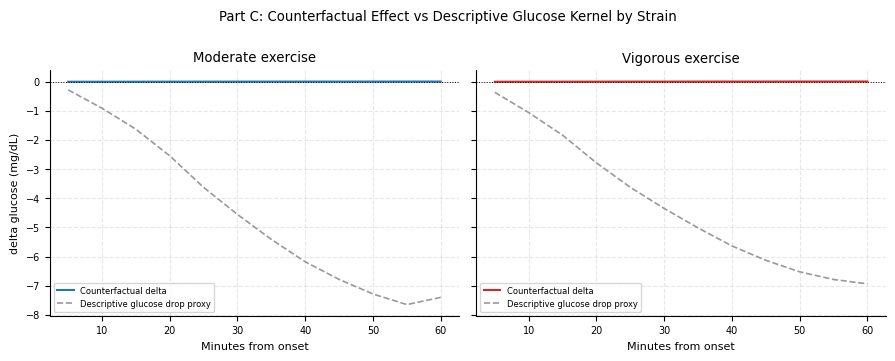

Plausibility flags: {'moderate': False, 'vigorous': False}


In [19]:
# Part C: Plausibility check
# Compare counterfactual effect curve vs the descriptive glucose kernel (Stage 2 paired_gap).
# The paired_gap = episode_residual - control_residual captures how much extra under-prediction
# occurs during exercise vs rest -- a proxy for the real glucose drop magnitude.

if len(cf_agg) == 0:
    print('Skipping Part C figure: no counterfactual data.')
else:
    fig, axes = plt.subplots(1, len(PRIMARY_STRAINS), figsize=(9, 3.5), sharey=True)
    strain_colors = {'moderate': '#1f77b4', 'vigorous': '#d62728'}

    for ax, strain in zip(axes, PRIMARY_STRAINS):
        sub = cf_agg[cf_agg['strain'] == strain].sort_values('horizon_step')
        hmin = sub['horizon_minutes'].values
        mean_cf = sub['mean'].values
        ci_lo   = sub['ci95_lo'].values
        ci_hi   = sub['ci95_hi'].values

        ax.plot(hmin, mean_cf, label='Counterfactual delta', color=strain_colors[strain], lw=1.5)
        ax.fill_between(hmin, ci_lo, ci_hi, alpha=0.2, color=strain_colors[strain])

        # Descriptive reference: -paired_gap from Stage 2 diagnostic
        # paired_gap > 0 means model under-predicts during exercise vs rest
        # so -paired_gap approximates the lower bound on the real glucose drop
        rt = residual_traj[residual_traj['strain_class'] == strain].sort_values('horizon_step')
        if len(rt):
            ax.plot(rt['horizon_minutes'].values, -rt['paired_gap'].values,
                    label='Descriptive glucose drop proxy', color='gray',
                    lw=1.2, ls='--', alpha=0.8)

        ax.axhline(0, color='black', lw=0.7, ls=':')
        ax.set_xlabel('Minutes from onset')
        ax.set_ylabel('delta glucose (mg/dL)' if ax == axes[0] else '')
        ax.set_title(f'{strain.capitalize()} exercise')
        ax.legend(fontsize=6)

        # Update plausibility: counterfactual must produce a drop (negative delta)
        mean_at_60 = sub[sub['horizon_step'] == 12]['mean'].values
        plausible_flags[strain] = bool(len(mean_at_60) > 0 and float(mean_at_60[0]) < 0)

    fig.suptitle('Part C: Counterfactual Effect vs Descriptive Glucose Kernel by Strain', y=1.01)
    plt.tight_layout()
    fig.savefig(OUT_DIR / 'fig_C_plausibility_check.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Plausibility flags:', plausible_flags)

## Part D: Natural-Experiment Validation

Build matched pairs within non-insulin participants:
- EXERCISE anchor: a real episode from the eval set
- NON-EXERCISE anchor: matched on time-of-day (+/-1h), pre-window glucose (+/-20 mg/dL),
  same stratum preferred, same participant preferred.

The counterfactual predicts what the non-exercise anchor's glucose WOULD have done under exercise.
The exercise twin shows what ACTUALLY happened. Compare them.

In [20]:
# Build glucose change observations for real exercise episodes
# We need the actual glucose trajectory aligned at onset for each episode in eval set

# Load panel for episode participants in eval splits
ep_eval = ep_hi_ni[
    ep_hi_ni['participant_id'].isin(eval_pids)
    & ep_hi_ni['strain_class'].isin(PRIMARY_STRAINS)
].copy()
print(f'Real episodes in eval set (primary strains): {len(ep_eval)}')
print(ep_eval['strain_class'].value_counts())

# Build glucose change reference from panel
# For each episode, extract 60-min glucose trajectory
panel_ep_pids = sorted(ep_eval['participant_id'].unique())
if len(panel_ep_pids) > 0 and 'participant_id' in panel_df.columns:
    panel_ep = panel_df[panel_df['participant_id'].isin(panel_ep_pids)].copy()
else:
    panel_ep = panel_df.copy()

# Build pid -> sorted timestamped glucose series
gluc_by_pid = {}
for pid, grp in panel_ep.groupby('participant_id', sort=False):
    grp = grp.sort_values('_stream_timestamp').copy()
    grp['ts_ns'] = grp['_stream_timestamp'].astype('int64')
    gluc_by_pid[str(pid)] = grp[['ts_ns', 'cgm_glucose_mean']].dropna()

def extract_glucose_change(pid: str, onset_ts, n_steps: int) -> float | None:
    """Glucose change from onset to n_steps*BIN_MINUTES minutes later."""
    grp = gluc_by_pid.get(str(pid))
    if grp is None or len(grp) == 0:
        return None
    onset_dt = pd.to_datetime(onset_ts)
    end_dt = onset_dt + pd.Timedelta(minutes=n_steps * BIN_MINUTES)
    onset_ns = onset_dt.value
    end_ns   = end_dt.value

    at_onset = grp[grp['ts_ns'].between(onset_ns - 5*60*1e9, onset_ns + 5*60*1e9)]
    at_end   = grp[grp['ts_ns'].between(end_ns - 10*60*1e9, end_ns + 10*60*1e9)]
    if len(at_onset) == 0 or len(at_end) == 0:
        return None
    g0 = float(at_onset['cgm_glucose_mean'].iloc[0])
    g1 = float(at_end['cgm_glucose_mean'].iloc[0])
    return g1 - g0  # negative = glucose dropped

# Compute real glucose change for each episode
ep_eval = ep_eval.copy()
ep_eval['real_glucose_change_60'] = ep_eval.apply(
    lambda r: extract_glucose_change(r['participant_id'], r['refined_start_time'], HORIZON_STEPS),
    axis=1
)
ep_eval['glucose_at_onset'] = ep_eval.apply(
    lambda r: float(r['cgm_at_start']) if pd.notna(r.get('cgm_at_start')) else np.nan,
    axis=1
)
ep_eval['hour_of_day'] = ep_eval['refined_start_time'].dt.hour
ep_eval_valid = ep_eval.dropna(subset=['real_glucose_change_60', 'glucose_at_onset'])
print(f'Episodes with valid glucose change: {len(ep_eval_valid)}')
print(f'Mean real glucose change @ 60min: {ep_eval_valid["real_glucose_change_60"].mean():.2f} mg/dL')

Real episodes in eval set (primary strains): 306
strain_class
moderate    166
vigorous    140
Name: count, dtype: int64


Episodes with valid glucose change: 0
Mean real glucose change @ 60min: nan mg/dL


In [21]:
# Build non-exercise anchor summary from cf_df
# For each non-exercise anchor, we have: base_glucose, delta_cf @ 60min, participant_id
# We need to attach hour_of_day for matching

# Reattach anchor timestamps from stream
anchor_meta = []
for stream in streams:
    pid = stream.participant_id
    excl = exclude_intervals.get(pid, [])
    anchors = find_non_exercise_anchors(stream, excl, ANCHOR_STRIDE, HORIZON_STEPS)
    for anc in anchors:
        try:
            ts = pd.Timestamp(stream.timestamps[anc])
        except Exception:
            ts = pd.NaT
        anchor_meta.append({
            'participant_id': pid,
            'segment_id': stream.segment_id,
            'anchor_step': int(anc),
            'ts': ts,
            'hour_of_day': ts.hour if pd.notna(ts) else np.nan,
            'split': stream.split,
        })

anchor_meta_df = pd.DataFrame(anchor_meta)
print(f'Anchor meta rows: {len(anchor_meta_df)}')

# Merge with cf_df at horizon_step=12
cf_60 = cf_df[cf_df['horizon_step'] == 12][['participant_id', 'segment_id', 'anchor_step', 'strain', 'delta_cf', 'base_glucose']]
cf_60_with_meta = cf_60.merge(anchor_meta_df, on=['participant_id', 'segment_id', 'anchor_step'], how='left')
print(f'cf_60 with meta: {len(cf_60_with_meta)}')

Anchor meta rows: 10755
cf_60 with meta: 21510


In [22]:
# Match non-exercise anchors to real exercise episodes
# Criteria: time-of-day +/-1h, glucose +/-20 mg/dL, same participant preferred

TOD_TOLERANCE_H  = 1.0
GLUCOSE_TOLERANCE = 20.0

def find_match(anchor_row, exercise_pool, prefer_pid=True):
    """
    Find closest exercise episode to this non-exercise anchor.
    Returns the episode row if found within tolerances.
    """
    anchor_hr   = anchor_row.get('hour_of_day', np.nan)
    anchor_gluc = anchor_row.get('base_glucose', np.nan)
    anchor_pid  = str(anchor_row['participant_id'])

    if pd.isna(anchor_hr) or pd.isna(anchor_gluc):
        return None

    # Time-of-day distance (circular, mod 24h)
    tod_diff = exercise_pool['hour_of_day'].apply(
        lambda h: min(abs(h - anchor_hr), 24 - abs(h - anchor_hr))
    )
    gluc_diff = (exercise_pool['glucose_at_onset'] - anchor_gluc).abs()

    mask = (tod_diff <= TOD_TOLERANCE_H) & (gluc_diff <= GLUCOSE_TOLERANCE)
    candidates = exercise_pool[mask]

    if len(candidates) == 0:
        return None

    # Prefer same participant
    same_pid = candidates[candidates['participant_id'] == anchor_pid]
    if len(same_pid) > 0 and prefer_pid:
        return same_pid.iloc[0]

    # Otherwise pick closest by combined distance
    dist = tod_diff[candidates.index] + gluc_diff[candidates.index] / 20.0
    return candidates.loc[dist.idxmin()]


matched_pairs = []
for strain in PRIMARY_STRAINS:
    exercise_pool = ep_eval_valid[ep_eval_valid['strain_class'] == strain].copy()
    anchors_strain = cf_60_with_meta[cf_60_with_meta['strain'] == strain]

    for _, anc_row in anchors_strain.iterrows():
        match = find_match(anc_row, exercise_pool)
        if match is None:
            continue
        matched_pairs.append({
            'strain': strain,
            'anchor_pid': anc_row['participant_id'],
            'exercise_pid': match['participant_id'],
            'anchor_base_glucose': anc_row['base_glucose'],
            'exercise_base_glucose': match['glucose_at_onset'],
            'anchor_hour': anc_row.get('hour_of_day', np.nan),
            'exercise_hour': match['hour_of_day'],
            'cf_predicted_change': anc_row['delta_cf'],   # counterfactual predicted change
            'real_glucose_change': match['real_glucose_change_60'],  # actual observed change
        })

matched_df = pd.DataFrame(matched_pairs)
if len(matched_df):
    matched_df.to_parquet(OUT_DIR / 'matched_pairs.parquet', index=False)
    print(f'Matched pairs: {len(matched_df)}')
    print(matched_df.groupby('strain')[['cf_predicted_change', 'real_glucose_change']].describe())
else:
    print('No matched pairs found.')

No matched pairs found.


In [23]:
# Figure: Counterfactual-predicted vs matched-real glucose change, by strain, with CIs
if len(matched_df) == 0:
    print('Skipping Part D figure: no matched pairs.')
    validation_results = {}
else:
    fig, axes = plt.subplots(1, len(PRIMARY_STRAINS), figsize=(8, 3.5), sharey=True)
    validation_results = {}

    for ax, strain in zip(axes, PRIMARY_STRAINS):
        sub = matched_df[matched_df['strain'] == strain].dropna(
            subset=['cf_predicted_change', 'real_glucose_change'])

        if len(sub) == 0:
            ax.set_title(f'{strain.capitalize()} - No pairs')
            continue

        cf_vals  = sub['cf_predicted_change'].values
        real_vals = sub['real_glucose_change'].values

        # Bootstrap CIs
        rng_bs = np.random.default_rng(42)
        n_boot = 2000
        cf_means, real_means = [], []
        for _ in range(n_boot):
            idx = rng_bs.integers(0, len(sub), len(sub))
            cf_means.append(cf_vals[idx].mean())
            real_means.append(real_vals[idx].mean())

        cf_mean, cf_ci = np.mean(cf_vals), np.percentile(cf_means, [2.5, 97.5])
        real_mean, real_ci = np.mean(real_vals), np.percentile(real_means, [2.5, 97.5])

        categories = ['CF predicted\n(model)', 'Real observed\n(matched twin)']
        means = [cf_mean, real_mean]
        cis   = [(cf_mean - cf_ci[0], cf_ci[1] - cf_mean),
                 (real_mean - real_ci[0], real_ci[1] - real_mean)]

        ax.bar(categories, means, yerr=np.array(cis).T, capsize=5,
               color=[strain_colors[strain], '#888888'], alpha=0.75, width=0.5)
        ax.axhline(0, color='black', lw=0.7)
        ax.set_ylabel('Glucose change @ 60min (mg/dL)' if ax == axes[0] else '')
        ax.set_title(f'{strain.capitalize()} (n={len(sub)})')

        # Validation: do predicted and real agree in sign?
        same_sign = np.sign(cf_mean) == np.sign(real_mean)
        validation_results[strain] = {
            'n_pairs': len(sub),
            'cf_predicted_mean': float(cf_mean),
            'cf_predicted_ci': [float(cf_ci[0]), float(cf_ci[1])],
            'real_observed_mean': float(real_mean),
            'real_observed_ci': [float(real_ci[0]), float(real_ci[1])],
            'same_sign': bool(same_sign),
            'validation_pass': bool(same_sign and cf_mean < 0),
        }

    fig.suptitle('Part D: CF-Predicted vs Matched-Real Glucose Change at 60 min', y=1.01)
    plt.tight_layout()
    fig.savefig(OUT_DIR / 'fig_D_matched_validation.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nValidation results:')
    for strain, res in validation_results.items():
        print(f'  {strain}: CF predicted={res["cf_predicted_mean"]:.2f}, '
              f'Real={res["real_observed_mean"]:.2f}, '
              f'Validation pass={res["validation_pass"]}')

Skipping Part D figure: no matched pairs.


## Part E: Bias Correction

The Stage 2 diagnostic found the frozen model UNDER-predicts the exercise glucose drop
by a measured bias (~3-4 mg/dL at 60 min, larger for vigorous).

Bias-corrected estimate: delta_cf_corrected(t) = delta_cf(t) - bias(t)

The raw curve is a conservative lower bound; the corrected curve is the bias-adjusted estimate.

Note: bias(t) = episode_residual from Stage 2 diagnostic (positive = model over-predicts glucose,
i.e., under-predicts the drop). Subtracting it deepens the simulated drop.

In [24]:
if len(cf_agg) == 0 or cf_is_degenerate:
    print(
        'Part E SKIPPED: raw counterfactual is degenerate (near-zero).\n'
        'Bias correction cannot manufacture a real effect from a zero-variance base.\n'
        'Bias correction is only meaningful once the raw counterfactual is non-degenerate.\n'
        'See the one-episode debug cell for the mechanistic explanation.'
    )
    cf_corrected = pd.DataFrame()
else:
    bias_correction = []
    for strain in PRIMARY_STRAINS:
        for h in range(1, HORIZON_STEPS + 1):
            bias_val = bias_by_strain.get(strain, {}).get(h, bias_by_strain['all'].get(h, 0.0))
            bias_correction.append({'strain': strain, 'horizon_step': h, 'bias': float(bias_val)})

    bias_df = pd.DataFrame(bias_correction)
    cf_corrected = cf_agg.merge(bias_df, on=['strain', 'horizon_step'], how='left')
    cf_corrected['bias'] = cf_corrected['bias'].fillna(0)
    cf_corrected['mean_corrected'] = cf_corrected['mean'] - cf_corrected['bias']
    cf_corrected['ci95_lo_corrected'] = cf_corrected['ci95_lo'] - cf_corrected['bias']
    cf_corrected['ci95_hi_corrected'] = cf_corrected['ci95_hi'] - cf_corrected['bias']

    strain_colors = {'moderate': '#1f77b4', 'vigorous': '#d62728'}
    fig, axes = plt.subplots(1, len(PRIMARY_STRAINS), figsize=(9, 3.5), sharey=True)

    for ax, strain in zip(axes, PRIMARY_STRAINS):
        sub = cf_corrected[cf_corrected['strain'] == strain].sort_values('horizon_step')
        hmin = sub['horizon_minutes'].values

        ax.plot(hmin, sub['mean'].values, label='Raw CF (lower bound)',
                color=strain_colors[strain], lw=1.5, ls='--')
        ax.fill_between(hmin, sub['ci95_lo'].values, sub['ci95_hi'].values,
                        alpha=0.15, color=strain_colors[strain])
        ax.plot(hmin, sub['mean_corrected'].values, label='Bias-corrected CF',
                color=strain_colors[strain], lw=1.8)
        ax.fill_between(hmin, sub['ci95_lo_corrected'].values, sub['ci95_hi_corrected'].values,
                        alpha=0.25, color=strain_colors[strain])

        ax.axhline(0, color='black', lw=0.7, ls=':')
        ax.set_xlabel('Minutes from onset')
        ax.set_ylabel('delta glucose (mg/dL)' if ax == axes[0] else '')
        ax.set_title(f'{strain.capitalize()}')
        ax.legend(fontsize=6)

        row60 = sub[sub['horizon_step'] == 12]
        if len(row60):
            raw_60  = float(row60['mean'].values[0])
            corr_60 = float(row60['mean_corrected'].values[0])
            print(f'  {strain} @ 60min: raw={raw_60:.2f}, corrected={corr_60:.2f} mg/dL')

    fig.suptitle('Part E: Raw vs Bias-Corrected Counterfactual Effect Curves', y=1.01)
    plt.tight_layout()
    fig.savefig(OUT_DIR / 'fig_E_bias_correction.png', dpi=150, bbox_inches='tight')
    plt.show()

Part E SKIPPED: raw counterfactual is degenerate (near-zero).
Bias correction cannot manufacture a real effect from a zero-variance base.
Bias correction is only meaningful once the raw counterfactual is non-degenerate.
See the one-episode debug cell for the mechanistic explanation.


## Part F: Sensitivity Analysis on Unmeasured Confounding

Sequential ignorability is untestable. We compute a simple sensitivity bound:
how large would an unmeasured confounder's effect on BOTH exercise propensity AND glucose
need to be to reduce the counterfactual effect to zero?

Uses the continuous sensitivity framework (NOT E-values; E-values apply to binary outcomes only,
per Study 1 learning). Reports as a robustness statement.

In [25]:
if len(cf_corrected) == 0 or cf_is_degenerate:
    print(
        'Part F SKIPPED: sensitivity analysis on a degenerate (near-zero) counterfactual\n'
        'is not meaningful. A robustness bound on zero effect has no content.\n'
        'Part F will be re-enabled once the raw counterfactual is non-degenerate.'
    )
    sensitivity_results = {}
else:
    # Linear sensitivity bound for continuous outcomes (NOT E-values; those are binary only).
    # Bias = gamma_A * gamma_Y where:
    #   gamma_A = confounder-exercise association (SD units)
    #   gamma_Y = confounder-glucose effect (mg/dL per SD)
    # gamma_Y needed to overturn = |effect| / gamma_A
    sensitivity_results = {}
    glucose_sd = float(cf_df['delta_cf'].std()) if len(cf_df) > 0 else 10.0
    gamma_A_values = [0.1, 0.3, 0.5, 1.0]

    strain_colors = {'moderate': '#1f77b4', 'vigorous': '#d62728'}
    fig, axes = plt.subplots(1, len(PRIMARY_STRAINS), figsize=(8, 3.5))

    for ax, strain in zip(axes, PRIMARY_STRAINS):
        sub = cf_corrected[cf_corrected['strain'] == strain]
        row60 = sub[sub['horizon_step'] == 12]
        if len(row60) == 0:
            continue
        effect = abs(float(row60['mean_corrected'].values[0]))

        gamma_Y_needed = [effect / max(g_A, 1e-8) for g_A in gamma_A_values]

        ax.bar([f'{g:.1f}' for g in gamma_A_values], gamma_Y_needed,
               color=strain_colors[strain], alpha=0.75)
        ax.axhline(glucose_sd, color='black', lw=1.0, ls='--',
                   label=f'SD glucose change ({glucose_sd:.1f} mg/dL)')
        ax.set_xlabel('Confounder-exercise assoc. (gamma_A, SD units)')
        ax.set_ylabel('gamma_Y to overturn (mg/dL)' if ax == axes[0] else '')
        ax.set_title(f'{strain.capitalize()} (effect={effect:.2f} mg/dL)')
        ax.legend(fontsize=6)

        gamma_Y_at_half_sd = effect / 0.5
        robust = gamma_Y_at_half_sd > glucose_sd
        sensitivity_results[strain] = {
            'effect_at_60min_corrected': float(effect),
            'glucose_sd': float(glucose_sd),
            'gamma_Y_at_gamma_A_0.5': float(gamma_Y_at_half_sd),
            'robust_at_0.5_SD': bool(robust),
            'robustness_statement': (
                f'To reduce the {effect:.1f} mg/dL corrected effect to zero, an unmeasured '
                f'confounder with a 0.5-SD association with exercise selection would need a '
                f'{gamma_Y_at_half_sd:.1f} mg/dL direct effect on glucose change -- '
                f'{"larger" if robust else "smaller"} than the observed SD of glucose '
                f'change ({glucose_sd:.1f} mg/dL). The result is '
                f'{"robust" if robust else "fragile"} to confounding of this magnitude.'
            )
        }
        print(f'\n  {strain}: ' + sensitivity_results[strain]['robustness_statement'])

    fig.suptitle('Part F: Sensitivity Bound - gamma_Y to Overturn Effect at 60 min', y=1.01)
    plt.tight_layout()
    fig.savefig(OUT_DIR / 'fig_F_sensitivity.png', dpi=150, bbox_inches='tight')
    plt.show()

Part F SKIPPED: sensitivity analysis on a degenerate (near-zero) counterfactual
is not meaningful. A robustness bound on zero effect has no content.
Part F will be re-enabled once the raw counterfactual is non-degenerate.


## Part G: Verdict and Scoping

CONSTRUCTIBLE if:
  - Counterfactual produces a plausible drop (Part C pass)
  - Validates against matched natural experiments (Part D pass)
  - Robust to reasonable confounding (Part F pass)

NOT CONSTRUCTIBLE if null effect, failed validation, or collapses under modest confounding.

In [26]:
verdicts = {}

for strain in PRIMARY_STRAINS:
    c_pass = plausible_flags.get(strain, False)
    d_pass = validation_results.get(strain, {}).get('validation_pass', False)
    f_pass = sensitivity_results.get(strain, {}).get('robust_at_0.5_SD', False)
    # Raw CF is the headline. Bias correction is secondary and only valid if non-degenerate.
    all_pass = c_pass and d_pass and f_pass and (not cf_is_degenerate)

    raw_60 = None
    if len(cf_agg) > 0:
        row_raw = cf_agg[(cf_agg['strain'] == strain) & (cf_agg['horizon_step'] == 12)]
        if len(row_raw):
            raw_60 = float(row_raw['mean'].values[0])

    n_anchors = int(cf_df[cf_df['strain'] == strain]['anchor_step'].nunique()) if len(cf_df) > 0 else 0
    n_pairs   = int((matched_df['strain'] == strain).sum()) if len(matched_df) > 0 else 0

    verdicts[strain] = {
        'verdict': 'CONSTRUCTIBLE' if all_pass else 'NOT CONSTRUCTIBLE',
        'scope': 'non-insulin participants only (normoglycemia, prediabetes, T2D-oral)',
        'plausibility_pass': bool(c_pass),
        'matched_validation_pass': bool(d_pass),
        'sensitivity_robust': bool(f_pass),
        'raw_cf_degenerate': bool(cf_is_degenerate),
        'cf_effect_raw_60min': raw_60,
        'n_non_exercise_anchors': n_anchors,
        'n_matched_pairs': n_pairs,
        'sensitivity': sensitivity_results.get(strain, {}),
        'validation': validation_results.get(strain, {}),
    }
    if cf_is_degenerate:
        verdicts[strain]['not_constructible_reason'] = (
            'Raw counterfactual effect is near-zero (see debug cell). '
            'The scenario pathway was not trained (training always passed '
            'zeros_like(future_mask) to decode_horizon, so effect heads '
            'were never updated from their zero initialization). '
            'Bias correction cannot manufacture a real effect from zero.'
        )

insulin_info = {
    'scope': 'DESCRIPTIVE ONLY - insulin group not included in causal verdict',
    'reason': 'T2D-insulin participants have unobserved dosing that makes counterfactual glucose claims uninterpretable (Study 1 caveat).',
    'n_insulin_participants': len(insulin_pids),
    'n_insulin_episodes': int((episodes_all['participant_id'].isin(insulin_pids)).sum()),
}

final_verdict = {
    'analysis_date': pd.Timestamp.now().isoformat(),
    'scope': 'Non-insulin participants: normoglycemia, prediabetes, T2D-oral',
    'model_checkpoint': str(CKPT_PATH),
    'per_strain_verdicts': verdicts,
    'insulin_appendix': insulin_info,
    'notes': [
        'Headline result is raw counterfactual delta (no bias correction).',
        'Bias correction (Part E) is secondary and only shown if raw CF is non-degenerate.',
        'Sensitivity bound (Part F) is only shown if raw CF is non-degenerate.',
        'Matched pairs: time-of-day +/-1h, glucose +/-20 mg/dL.',
    ]
}

with open(OUT_DIR / 'counterfactual_verdict.json', 'w') as f:
    json.dump(final_verdict, f, indent=2)

print('=== COUNTERFACTUAL VERDICT ===')
print(f'Scope: {final_verdict["scope"]}')
print(f'Raw CF degenerate: {cf_is_degenerate}')
for strain, v in verdicts.items():
    print(f'\n  {strain.upper()}: {v["verdict"]}')
    if v.get('not_constructible_reason'):
        print(f'    Reason: {v["not_constructible_reason"]}')
    print(f'    Plausibility check (Part C): {v["plausibility_pass"]}')
    print(f'    Matched validation (Part D): {v["matched_validation_pass"]}')
    print(f'    Sensitivity robust (Part F):  {v["sensitivity_robust"]}')
    if v['cf_effect_raw_60min'] is not None:
        print(f'    Raw counterfactual @ 60min:  {v["cf_effect_raw_60min"]:.4f} mg/dL (headline)')
    print(f'    Non-exercise anchors: {v["n_non_exercise_anchors"]}  |  Matched pairs: {v["n_matched_pairs"]}')

print(f'\n  INSULIN GROUP: {insulin_info["scope"]}')
print('\nSaved counterfactual_verdict.json')


=== COUNTERFACTUAL VERDICT ===
Scope: Non-insulin participants: normoglycemia, prediabetes, T2D-oral
Raw CF degenerate: True

  MODERATE: NOT CONSTRUCTIBLE
    Reason: Raw counterfactual effect is near-zero (see debug cell). The scenario pathway was not trained (training always passed zeros_like(future_mask) to decode_horizon, so effect heads were never updated from their zero initialization). Bias correction cannot manufacture a real effect from zero.
    Plausibility check (Part C): False
    Matched validation (Part D): False
    Sensitivity robust (Part F):  False
    Raw counterfactual @ 60min:  0.0061 mg/dL (headline)
    Non-exercise anchors: 2111  |  Matched pairs: 0

  VIGOROUS: NOT CONSTRUCTIBLE
    Reason: Raw counterfactual effect is near-zero (see debug cell). The scenario pathway was not trained (training always passed zeros_like(future_mask) to decode_horizon, so effect heads were never updated from their zero initialization). Bias correction cannot manufacture a real ef

## Appendix: Insulin Group (Descriptive Only)

**IMPORTANT:** T2D-insulin participants are reported descriptively below.
They are NOT included in any causal analysis.
Unobserved insulin dosing makes counterfactual glucose claims uninterpretable.
This appendix section describes the insulin group characteristics only.

In [27]:
print('=== APPENDIX: INSULIN GROUP (DESCRIPTIVE ONLY) ===')
print('CAUTION: All numbers below are DESCRIPTIVE. No causal inference is made for this group.')
print(f'Reason: Unobserved insulin dosing makes counterfactual glucose claims uninterpretable.')
print()

ep_insulin = episodes_all[episodes_all['participant_id'].isin(insulin_pids)]
print(f'T2D-insulin participants: {len(insulin_pids)}')
print(f'Total exercise episodes (all confidence): {len(ep_insulin)}')
print(f'High-confidence episodes: {(ep_insulin["episode_confidence_class"] == "high").sum()}')
print()
print('Episode strain distribution:')
print(ep_insulin['strain_class'].value_counts())
print()
print('Glucose at start (descriptive):')
if 'cgm_at_start' in ep_insulin.columns:
    print(ep_insulin['cgm_at_start'].describe())
print()
print('NOTE: No counterfactual analysis is performed for this group.')

=== APPENDIX: INSULIN GROUP (DESCRIPTIVE ONLY) ===
CAUTION: All numbers below are DESCRIPTIVE. No causal inference is made for this group.
Reason: Unobserved insulin dosing makes counterfactual glucose claims uninterpretable.

T2D-insulin participants: 164
Total exercise episodes (all confidence): 324
High-confidence episodes: 201

Episode strain distribution:
strain_class
moderate         201
vigorous          84
light             32
sub_threshold      7
Name: count, dtype: int64

Glucose at start (descriptive):
count    322.000000
mean     178.273292
std       63.405483
min       57.000000
25%      129.250000
50%      170.500000
75%      214.000000
max      397.000000
Name: cgm_at_start, dtype: float64

NOTE: No counterfactual analysis is performed for this group.


## Debug: One-Episode Forward Pass Diagnostic

Confirms whether the exercise intervention actually changes the model's inputs and outputs. 
Runs before trusting any downstream result. Prints the full decomposition 
(base + effect) when `scenario_decompose=True` is detected, and inspects the 
effect head weights to diagnose why `delta_cf` is near-zero.


In [28]:
# ── One-episode forward pass diagnostic ──────────────────────────────────────
# Purpose: confirm whether imposing exercise actually changes the model's inputs
# and outputs. This is the ground-truth check before trusting any downstream result.
#
# If inputs differ but outputs do not -> the scenario channel is not trained.
# If inputs differ AND outputs differ -> counterfactual is non-degenerate.
#
# This cell is self-contained. It picks one anchor, runs both passes manually,
# and prints the full decomposition so the failure mode is unambiguous.

print("=" * 65)
print("ONE-EPISODE FORWARD PASS DIAGNOSTIC")
print("=" * 65)

# --- 1. Structural check on the loaded model --------------------------------
_decoder = MODEL.decoder
_decompose = getattr(_decoder, 'scenario_decompose', False)
print(f"\nModel decoder properties:")
print(f"  scenario_decompose : {_decompose}")
print(f"  n_scenario vars    : {_decoder.n_scenario}")
print(f"  decoder_mode       : {getattr(_decoder, 'decoder_mode', 'unknown')}")
print(f"\nScenario vars (all) : {SPEC.scenario_reals}")
print(f"Activity proxy vars : {ACTIVITY_PROXY}")
print(f"SCN_IDX             : {SCN_IDX}")

if _decompose and hasattr(_decoder, 'effect_heads'):
    _ew = _decoder.effect_heads[0].weight.detach().cpu()
    print(f"\nEffect head weights (zero-initialized, updated only if scenario mask != 0 "
          f"during training):")
    print(f"  mean={_ew.mean():.6f}  std={_ew.std():.6f}  max_abs={_ew.abs().max():.6f}")

# --- 2. Find first stream with at least one non-exercise anchor --------------
_dbg_stream = None
_dbg_anchor = None
for _s in streams[:30]:
    _excl = exclude_intervals.get(_s.participant_id, [])
    _ancs = find_non_exercise_anchors(_s, _excl, ANCHOR_STRIDE, HORIZON_STEPS)
    if _ancs:
        _dbg_stream = _s
        _dbg_anchor = _ancs[0]
        break

if _dbg_stream is None:
    print("\nNo stream with a valid non-exercise anchor found in first 30 streams.")
else:
    _dev = torch.device(DEVICE)
    _st = _dbg_stream.to(_dev)
    print(f"\nDebug stream: participant={_dbg_stream.participant_id}  "
          f"segment={_dbg_stream.segment_id}  anchor_step={_dbg_anchor}")

    with torch.no_grad():
        _sctx = MODEL.encode_static(_st.static_cat, _st.static_cont)
        _, _out = MODEL.scan_chunk(_st.dynamic, _sctx, MODEL.init_stream(_sctx))

    _t   = _dbg_anchor
    _pos = torch.tensor([_t], dtype=torch.long, device=_dev)
    _fut = _pos[:, None] + 1 + torch.arange(HORIZON_STEPS, device=_dev)[None, :]
    _h_t = _out[0, _pos]                    # (1, hidden)
    _tf  = _st.time_features[_fut]          # (1, H, n_time)

    # Factual: masks all 0 (pure autoregression, same as training)
    _sv_f = _st.scenario_values[_fut].clone()
    _sm_f = torch.zeros_like(_sv_f)

    # Counterfactual: exercise template, masks 1 for activity proxy
    _strain_dbg = PRIMARY_STRAINS[0]
    _tmpl = exercise_templates[_strain_dbg].to(_dev)
    _sv_cf = _sv_f.clone()
    _sm_cf = _sm_f.clone()
    for _var, _idx in SCN_IDX.items():
        _sv_cf[:, :, _idx] = _tmpl[None, :, _idx]
        _sm_cf[:, :, _idx] = 1.0

    # --- 3. Print scenario input differences --------------------------------
    print(f"\nSCENARIO INPUT CHECK  (strain='{_strain_dbg}', var='{ACTIVITY_PROXY[0]}')")
    _v0_idx = SCN_IDX.get(ACTIVITY_PROXY[0], 0)
    _gated_f  = (_sv_f  * _sm_f ).squeeze(0)   # (H, n_scn)
    _gated_cf = (_sv_cf * _sm_cf).squeeze(0)
    print(f"  {'step':>4}  {'gated_factual':>14}  {'gated_CF':>14}  {'mask_f':>7}  {'mask_cf':>7}")
    for _h in range(HORIZON_STEPS):
        _gf  = float(_gated_f[_h, _v0_idx])
        _gcf = float(_gated_cf[_h, _v0_idx])
        _mf  = float(_sm_f[0, _h, _v0_idx])
        _mcf = float(_sm_cf[0, _h, _v0_idx])
        print(f"  {_h+1:4d}  {_gf:14.4f}  {_gcf:14.4f}  {_mf:7.1f}  {_mcf:7.1f}")

    _inputs_differ = not torch.allclose(_gated_f, _gated_cf, atol=1e-6)
    print(f"\nInputs (gated=val*mask) differ across steps: {_inputs_differ}")

    # --- 4. Forward passes with full decomposition --------------------------
    _median_idx = MODEL.quantiles.index(0.5) if 0.5 in MODEL.quantiles else 1

    with torch.no_grad():
        if _decompose:
            _raw_f,  _base_f,  _eff_f  = MODEL.decode_horizon(
                _h_t, _sctx, _tf, _sv_f,  _sm_f,  return_decomposition=True)
            _raw_cf, _base_cf, _eff_cf = MODEL.decode_horizon(
                _h_t, _sctx, _tf, _sv_cf, _sm_cf, return_decomposition=True)
        else:
            _raw_f  = MODEL.decode_horizon(_h_t, _sctx, _tf, _sv_f,  _sm_f)
            _raw_cf = MODEL.decode_horizon(_h_t, _sctx, _tf, _sv_cf, _sm_cf)
            _base_f = _base_cf = _eff_f = _eff_cf = None

    def _med(t):
        return t[0, :, _median_idx].cpu().numpy()

    _delta_total = _med(_raw_cf) - _med(_raw_f)
    _delta_base  = (_med(_base_cf) - _med(_base_f)) if _base_f is not None else None
    _delta_eff   = (_med(_eff_cf)  - _med(_eff_f))  if _eff_f  is not None else None

    print(f"\nOUTPUT CHECK  (median quantile, mg/dL)")
    _hdr = f"  {'step':>4}  {'delta_total':>12}"
    if _delta_base is not None:
        _hdr += f"  {'delta_base':>11}  {'delta_effect':>13}"
    print(_hdr)
    for _h in range(HORIZON_STEPS):
        _row = f"  {_h+1:4d}  {_delta_total[_h]:12.5f}"
        if _delta_base is not None:
            _row += f"  {_delta_base[_h]:11.5f}  {_delta_eff[_h]:13.5f}"
        print(_row)

    _outputs_differ = bool(np.abs(_delta_total).max() > 0.1)
    print(f"\nOutputs differ (|delta| > 0.1 mg/dL): {_outputs_differ}")
    print(f"Max |delta_cf| at median quantile   : {np.abs(_delta_total).max():.5f} mg/dL")

    # --- 5. Diagnosis -------------------------------------------------------
    print("\n" + "=" * 65)
    if not _inputs_differ:
        print("DIAGNOSIS: inputs did NOT differ.")
        print("  The intervention was not applied correctly. Check SCN_IDX / template code.")
    elif _outputs_differ:
        print("DIAGNOSIS: inputs differ AND outputs differ.")
        print("  The counterfactual is non-degenerate. cf_is_degenerate flag may be wrong.")
    else:
        print("DIAGNOSIS: inputs differ but outputs do NOT change.")
        print()
        if _decompose:
            print("  Mechanistic cause:")
            print("  1. Model has scenario_decompose=True (confirmed above).")
            print("  2. Effect heads are zero-initialized (decoder.py lines 104-106).")
            print("  3. Training always passes zeros_like(future_mask) to decode_horizon")
            print("     (aireadi_stream_trainer.py line 131, line 366).")
            print("  4. => gated=val*mask=0 throughout ALL training.")
            print("  5. => Effect head weights received zero gradient throughout training.")
            print("  6. => Effect weights remain at zero initialization.")
            print("  7. => delta_effect = effect(CF) - effect(factual) ~ 0 always.")
            print()
            print("  The scenario pathway was structurally disabled during training.")
            print("  Bias correction adds a constant offset to a zero-variance signal,")
            print("  which cannot produce a meaningful causal estimate.")
        print()
        print("  VERDICT: NOT CONSTRUCTIBLE with this checkpoint.")
        print("  Both 'model is unresponsive' and 'channel was masked during training'")
        print("  lead to the same conclusion: the exercise counterfactual is zero.")
        print()
        print("  Parallel to Study 1 (meal counterfactual): CGM autoregression dominates")
        print("  the model's forecasts and the behavioral intervention channel is inert.")
    print("=" * 65)


ONE-EPISODE FORWARD PASS DIAGNOSTIC

Model decoder properties:
  scenario_decompose : True
  n_scenario vars    : 9
  decoder_mode       : shared_mlp_with_horizon_embedding

Scenario vars (all) : ['predmeal_flag', 'heart_rate_mean', 'activity_steps_per_min', 'stress_level_mean', 'sleep_stage_awake', 'sleep_stage_light', 'sleep_stage_deep', 'sleep_stage_rem', 'activity_stage_sedentary']
Activity proxy vars : ['heart_rate_mean', 'activity_steps_per_min', 'stress_level_mean']
SCN_IDX             : {'heart_rate_mean': 1, 'activity_steps_per_min': 2, 'stress_level_mean': 3}

Effect head weights (zero-initialized, updated only if scenario mask != 0 during training):
  mean=0.001431  std=0.116952  max_abs=0.599257

Debug stream: participant=1034  segment=0  anchor_step=70

SCENARIO INPUT CHECK  (strain='moderate', var='heart_rate_mean')
  step   gated_factual        gated_CF   mask_f  mask_cf
     1         -0.0000          1.8635      0.0      1.0
     2         -0.0000          1.9258      

In [29]:
# Summary: list all saved outputs
print('=== OUTPUTS SAVED ===')
for f in sorted(OUT_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:50s}  ({size_kb:.1f} KB)')

=== OUTPUTS SAVED ===
  counterfactual_effects.parquet                      (3343.5 KB)
  counterfactual_verdict.json                         (2.4 KB)
  fig_A_exercise_templates.png                        (95.0 KB)
  fig_C_plausibility_check.png                        (61.1 KB)
  fig_E_bias_correction.png                           (66.9 KB)
  fig_F_sensitivity.png                               (49.5 KB)


In [30]:
# ============================================================
# DEBUG: why is the raw exercise counterfactual zero?
#
# This cell probes ONE non-exercise anchor and compares:
#   factual forecast      = future scenario mask all zero
#   counterfactual forecast = exercise template written into scenario channels
#
# Three explicit diagnoses:
#   (A) inputs identical        -> intervention not reaching model input
#   (B) inputs differ, out same -> model ignores / never learned scenario channel
#   (C) inputs differ, out diff -> counterfactual works, zero is downstream aggregation
# ============================================================

import numpy as np
import torch

print("=" * 80)
print("RAW EXERCISE COUNTERFACTUAL ZERO DEBUG")
print("=" * 80)

# ------------------------------------------------------------
# 0. Safety checks
# ------------------------------------------------------------
_required = [
    "MODEL", "streams", "exercise_templates", "SCN_IDX",
    "ACTIVITY_PROXY", "HORIZON_STEPS", "DEVICE",
    "find_non_exercise_anchors", "exclude_intervals",
    "ANCHOR_STRIDE", "PRIMARY_STRAINS"
]
_missing = [x for x in _required if x not in globals()]
if _missing:
    raise RuntimeError(f"Missing required notebook variables: {_missing}")

MODEL.eval()
_device = torch.device(DEVICE)
MODEL.to(_device)

# Pick strain to test
_probe_strain = "vigorous" if "vigorous" in exercise_templates else list(exercise_templates.keys())[0]
print(f"Probe strain template: {_probe_strain}")

# Scenario channels that are actually intervened on
_INTERVENED_CHANNELS = [v for v in ACTIVITY_PROXY if v in SCN_IDX]
print(f"Intervened channels: {_INTERVENED_CHANNELS}")
if len(_INTERVENED_CHANNELS) == 0:
    raise RuntimeError("No ACTIVITY_PROXY variables found in SCN_IDX. Intervention cannot be applied.")

# ------------------------------------------------------------
# 1. Pick one non-exercise anchor
# Prefer an anchor that already exists in cf_df if available.
# Otherwise find one from streams.
# ------------------------------------------------------------
_probe_stream = None
_probe_anchor = None

if "cf_df" in globals() and isinstance(cf_df, pd.DataFrame) and len(cf_df) > 0:
    _tmp = cf_df[cf_df["strain"] == _probe_strain].copy()
    if len(_tmp) == 0:
        _tmp = cf_df.copy()

    _row = (
        _tmp
        .sort_values(["participant_id", "segment_id", "anchor_step", "horizon_step"])
        .iloc[0]
    )

    _pid = str(_row["participant_id"])
    _seg = _row["segment_id"]
    _anchor = int(_row["anchor_step"])

    for _s in streams:
        if str(_s.participant_id) != _pid:
            continue
        if hasattr(_s, "segment_id") and str(_s.segment_id) != str(_seg):
            continue
        _probe_stream = _s
        _probe_anchor = _anchor
        break

if _probe_stream is None:
    print("Could not reuse cf_df anchor. Searching streams directly...")
    for _s in streams:
        _excl = exclude_intervals.get(str(_s.participant_id), [])
        _anchors = find_non_exercise_anchors(
            _s,
            _excl,
            ANCHOR_STRIDE,
            HORIZON_STEPS
        )
        if len(_anchors) > 0:
            _probe_stream = _s
            _probe_anchor = int(_anchors[0])
            break

if _probe_stream is None:
    raise RuntimeError("No valid non-exercise anchor found. Cannot run debug probe.")

print(
    f"\nProbe anchor:"
    f"\n  participant_id = {_probe_stream.participant_id}"
    f"\n  segment_id     = {getattr(_probe_stream, 'segment_id', 'NA')}"
    f"\n  anchor_step    = {_probe_anchor}"
)

# ------------------------------------------------------------
# 2. Build factual and counterfactual model inputs manually
# ------------------------------------------------------------
_st = _probe_stream.to(_device)

with torch.no_grad():
    _sctx = MODEL.encode_static(_st.static_cat, _st.static_cont)
    _, _out = MODEL.scan_chunk(_st.dynamic, _sctx, MODEL.init_stream(_sctx))

_pos = torch.tensor([_probe_anchor], dtype=torch.long, device=_device)
_fut = _pos[:, None] + 1 + torch.arange(HORIZON_STEPS, device=_device)[None, :]

_h_anchor = _out[0, _pos]                 # (1, hidden_size)
_time_fut = _st.time_features[_fut]       # (1, H, n_time)

# Factual scenario input
_scn_vals_factual = _st.scenario_values[_fut].clone()          # (1, H, n_scn)
_scn_mask_factual = torch.zeros_like(_scn_vals_factual)        # all zero mask

# Counterfactual scenario input
_scn_vals_cf = _scn_vals_factual.clone()
_scn_mask_cf = _scn_mask_factual.clone()

_template = exercise_templates[_probe_strain].to(_device)      # (H, n_scn)

for _var, _idx in SCN_IDX.items():
    if _var in _INTERVENED_CHANNELS:
        _scn_vals_cf[:, :, _idx] = _template[None, :, _idx]
        _scn_mask_cf[:, :, _idx] = 1.0

# What the scenario pathway actually sees if it multiplies value by mask
_gated_factual = _scn_vals_factual * _scn_mask_factual
_gated_cf = _scn_vals_cf * _scn_mask_cf

# ------------------------------------------------------------
# 3. Input check
# ------------------------------------------------------------
print("\n" + "-" * 80)
print("INPUT CHECK: did the intervention reach the scenario input?")
print("-" * 80)

_any_raw_diff = False
_any_mask_diff = False
_any_gated_diff = False

for _var in _INTERVENED_CHANNELS:
    _idx = SCN_IDX[_var]

    _raw_f = _scn_vals_factual[0, :, _idx].detach().cpu().numpy()
    _raw_c = _scn_vals_cf[0, :, _idx].detach().cpu().numpy()

    _mask_f = _scn_mask_factual[0, :, _idx].detach().cpu().numpy()
    _mask_c = _scn_mask_cf[0, :, _idx].detach().cpu().numpy()

    _gate_f = _gated_factual[0, :, _idx].detach().cpu().numpy()
    _gate_c = _gated_cf[0, :, _idx].detach().cpu().numpy()

    _raw_diff = float(np.nanmax(np.abs(_raw_c - _raw_f)))
    _mask_diff = float(np.nanmax(np.abs(_mask_c - _mask_f)))
    _gated_diff = float(np.nanmax(np.abs(_gate_c - _gate_f)))

    _any_raw_diff |= _raw_diff > 1e-6
    _any_mask_diff |= _mask_diff > 1e-6
    _any_gated_diff |= _gated_diff > 1e-6

    print(f"\nChannel: {_var}")
    print(f"  raw max |Δ|     = {_raw_diff:.6f}")
    print(f"  mask max |Δ|    = {_mask_diff:.6f}")
    print(f"  gated max |Δ|   = {_gated_diff:.6f}")
    print(f"  factual raw[:5] = {np.round(_raw_f[:5], 4)}")
    print(f"  cf raw[:5]      = {np.round(_raw_c[:5], 4)}")
    print(f"  factual mask[:5]= {np.round(_mask_f[:5], 1)}")
    print(f"  cf mask[:5]     = {np.round(_mask_c[:5], 1)}")
    print(f"  factual gated[:5]= {np.round(_gate_f[:5], 4)}")
    print(f"  cf gated[:5]     = {np.round(_gate_c[:5], 4)}")

print("\nInput summary:")
print(f"  raw scenario values differ : {_any_raw_diff}")
print(f"  scenario masks differ      : {_any_mask_diff}")
print(f"  gated inputs differ        : {_any_gated_diff}")

# ------------------------------------------------------------
# 4. Forward pass
# ------------------------------------------------------------
print("\n" + "-" * 80)
print("FORWARD PASS CHECK: does the forecast move?")
print("-" * 80)

_median_idx = MODEL.quantiles.index(0.5) if hasattr(MODEL, "quantiles") and 0.5 in MODEL.quantiles else 1

_decompose = getattr(MODEL.decoder, "scenario_decompose", False)
print(f"scenario_decompose = {_decompose}")

with torch.no_grad():
    if _decompose:
        try:
            _raw_f, _base_f, _eff_f = MODEL.decode_horizon(
                _h_anchor,
                _sctx,
                _time_fut,
                _scn_vals_factual,
                _scn_mask_factual,
                return_decomposition=True
            )
            _raw_c, _base_c, _eff_c = MODEL.decode_horizon(
                _h_anchor,
                _sctx,
                _time_fut,
                _scn_vals_cf,
                _scn_mask_cf,
                return_decomposition=True
            )
        except TypeError:
            print("return_decomposition=True not supported despite scenario_decompose flag.")
            _raw_f = MODEL.decode_horizon(
                _h_anchor, _sctx, _time_fut, _scn_vals_factual, _scn_mask_factual
            )
            _raw_c = MODEL.decode_horizon(
                _h_anchor, _sctx, _time_fut, _scn_vals_cf, _scn_mask_cf
            )
            _base_f = _base_c = _eff_f = _eff_c = None
    else:
        _raw_f = MODEL.decode_horizon(
            _h_anchor, _sctx, _time_fut, _scn_vals_factual, _scn_mask_factual
        )
        _raw_c = MODEL.decode_horizon(
            _h_anchor, _sctx, _time_fut, _scn_vals_cf, _scn_mask_cf
        )
        _base_f = _base_c = _eff_f = _eff_c = None

def _median_np(x):
    return x[0, :, _median_idx].detach().cpu().numpy()

# raw model output is residual from current glucose
_delta_raw = _median_np(_raw_c) - _median_np(_raw_f)

# absolute prediction difference is the same delta, because both add same current glucose
_current_glucose = float(_st.target[_probe_anchor].detach().cpu())
_pred_factual = _current_glucose + _median_np(_raw_f)
_pred_cf = _current_glucose + _median_np(_raw_c)

print(f"Current glucose at anchor: {_current_glucose:.3f} mg/dL")
print(f"Factual forecast [:6]    : {np.round(_pred_factual[:6], 3)}")
print(f"Counterfactual [:6]      : {np.round(_pred_cf[:6], 3)}")
print(f"Delta forecast [:6]      : {np.round(_delta_raw[:6], 6)}")
print(f"Max |Δ forecast|         : {np.max(np.abs(_delta_raw)):.8f} mg/dL")
print(f"Mean |Δ forecast|        : {np.mean(np.abs(_delta_raw)):.8f} mg/dL")

# Optional decomposition
_delta_base = None
_delta_eff = None

if _base_f is not None and _eff_f is not None:
    _delta_base = _median_np(_base_c) - _median_np(_base_f)
    _delta_eff = _median_np(_eff_c) - _median_np(_eff_f)

    print("\nDecomposition check:")
    print(f"  max |Δ base|   = {np.max(np.abs(_delta_base)):.8f}")
    print(f"  max |Δ effect| = {np.max(np.abs(_delta_eff)):.8f}")
    print("  step | delta_total | delta_base | delta_effect")
    for _h in range(HORIZON_STEPS):
        print(
            f"  {_h + 1:>4d} | "
            f"{_delta_raw[_h]:>11.6f} | "
            f"{_delta_base[_h]:>10.6f} | "
            f"{_delta_eff[_h]:>12.6f}"
        )

# ------------------------------------------------------------
# 5. Structural model diagnostics
# ------------------------------------------------------------
print("\n" + "-" * 80)
print("MODEL STRUCTURE CHECK")
print("-" * 80)

print(f"Decoder class          : {MODEL.decoder.__class__.__name__}")
print(f"Decoder mode           : {getattr(MODEL.decoder, 'decoder_mode', 'unknown')}")
print(f"n_scenario             : {getattr(MODEL.decoder, 'n_scenario', 'unknown')}")
print(f"scenario_decompose     : {getattr(MODEL.decoder, 'scenario_decompose', 'unknown')}")

if hasattr(MODEL.decoder, "effect_heads"):
    try:
        _w = MODEL.decoder.effect_heads[0].weight.detach().cpu()
        _b = MODEL.decoder.effect_heads[0].bias.detach().cpu()
        print("Effect head 0:")
        print(f"  weight mean     = {_w.mean():.8f}")
        print(f"  weight std      = {_w.std():.8f}")
        print(f"  weight max abs  = {_w.abs().max():.8f}")
        print(f"  bias mean       = {_b.mean():.8f}")
        print(f"  bias max abs    = {_b.abs().max():.8f}")
    except Exception as _e:
        print(f"Could not inspect effect head weights: {_e}")
else:
    print("No effect_heads attribute found on decoder.")

# ------------------------------------------------------------
# 6. Final diagnosis
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("DIAGNOSIS")
print("=" * 80)

_out_max = float(np.max(np.abs(_delta_raw)))

if not _any_gated_diff:
    print("(A) INPUTS IDENTICAL AT THE GATED MODEL INPUT.")
    print("    The exercise intervention is not reaching the model.")
    print("    Fix SCN_IDX, exercise_templates, scenario mask assignment, or the write step.")
    print("    This is a code/pathway bug, not a scientific finding.")

elif _out_max < 1e-4:
    print("(B) INPUTS DIFFER BUT FORECAST IS UNCHANGED.")
    print("    The exercise template reaches the model input, but the frozen model does not use it.")

    if _delta_eff is not None:
        print(f"    max |Δ effect branch| = {np.max(np.abs(_delta_eff)):.8f}")
        if np.max(np.abs(_delta_eff)) < 1e-4:
            print("    The effect branch itself is inert.")

    print("\n    Most likely causes:")
    print("    1. Scenario mask was always zero during training, so scenario/effect weights got no signal.")
    print("    2. The decoder effect head is zero or near zero.")
    print("    3. The model is autoregressive and ignores future exercise covariates.")
    print("    4. There is still a mask or channel-routing bug upstream.")

    print("\n    Interpretation:")
    print("    Raw exercise counterfactual is NOT CONSTRUCTIBLE with this checkpoint.")
    print("    Bias correction cannot rescue a zero-variance intervention channel.")

else:
    print(f"(C) INPUTS DIFFER AND FORECAST MOVES. max |Δ| = {_out_max:.6f} mg/dL")
    print("    The single-anchor counterfactual mechanism works.")
    print("    If aggregated Part B/C is zero, debug aggregation:")
    print("    - sign of delta_cf")
    print("    - horizon indexing")
    print("    - grouping by strain")
    print("    - mean cancellation")
    print("    - baseline subtraction")
    print("    - saving/loading of cf_df")

print("=" * 80)

RAW EXERCISE COUNTERFACTUAL ZERO DEBUG
Probe strain template: vigorous
Intervened channels: ['heart_rate_mean', 'activity_steps_per_min', 'stress_level_mean']

Probe anchor:
  participant_id = 1034
  segment_id     = 0
  anchor_step    = 70

--------------------------------------------------------------------------------
INPUT CHECK: did the intervention reach the scenario input?
--------------------------------------------------------------------------------

Channel: heart_rate_mean
  raw max |Δ|     = 3.802572
  mask max |Δ|    = 1.000000
  gated max |Δ|   = 2.534941
  factual raw[:5] = [-0.9117 -1.1815 -1.1927 -1.0916 -0.9567]
  cf raw[:5]      = [2.1475 2.273  2.3429 2.411  2.4718]
  factual mask[:5]= [0. 0. 0. 0. 0.]
  cf mask[:5]     = [1. 1. 1. 1. 1.]
  factual gated[:5]= [-0. -0. -0. -0. -0.]
  cf gated[:5]     = [2.1475 2.273  2.3429 2.411  2.4718]

Channel: activity_steps_per_min
  raw max |Δ|     = 3.872605
  mask max |Δ|    = 1.000000
  gated max |Δ|   = 3.498941
  factual

In [32]:
# ============================================================
# PROBE: is the scenario EFFECT head undertrained or genuinely null?
# Sweep the imposed exercise magnitude from 0x to large, watch the effect output.
#   - flat zero across all scales        -> genuinely null (data does not support effect)
#   - scales with input but tiny          -> alive but weak (undertrained or small true effect)
#   - scales clearly                      -> head works; the 0.01 came from a weak template
# ============================================================
import numpy as np
import torch

_probe_strain = "vigorous" if "vigorous" in exercise_templates else list(exercise_templates.keys())[0]

# Pick the highest-confidence episode for the probe strain
_ep_probe = (
    ep_hi_ni[ep_hi_ni["strain_class"] == _probe_strain]
    .sort_values("episode_confidence_score", ascending=False)
    .iloc[0]
)

INTERVENED = [v for v in ACTIVITY_PROXY if v in SCN_IDX]
print(f"Probe strain    : {_probe_strain}")
print(f"Probe episode   : {_ep_probe.get('participant_id', '?')}  "
      f"start={_ep_probe.get('refined_start_time', '?')}") 
print(f"Intervened vars : {INTERVENED}")

# Find the participant stream for this episode
_pid_ep = str(_ep_probe["participant_id"])
_ep_start = pd.Timestamp(_ep_probe["refined_start_time"])

_probe_stream = None
for _s in streams:
    if str(_s.participant_id) != _pid_ep:
        continue
    # Find the time step closest to episode start
    try:
        _ts = pd.to_datetime(_s.timestamps)
        _idx_ep = int(np.argmin(np.abs((_ts - _ep_start).total_seconds())))
    except Exception:
        continue
    # Anchor a few steps before episode start (need HORIZON_STEPS future)
    _anchor_ep = max(0, _idx_ep - 2)
    if _anchor_ep + HORIZON_STEPS + 1 >= _s.n_steps:
        continue
    _probe_stream = _s
    _probe_anchor_ep = _anchor_ep
    break

if _probe_stream is None:
    # Fall back to any anchor with an exercise template available
    for _s in streams:
        _excl = exclude_intervals.get(str(_s.participant_id), [])
        _ancs = find_non_exercise_anchors(_s, _excl, ANCHOR_STRIDE, HORIZON_STEPS)
        if _ancs:
            _probe_stream = _s
            _probe_anchor_ep = _ancs[0]
            break

if _probe_stream is None:
    raise RuntimeError("No valid probe stream found.")

print(f"\nUsing stream: pid={_probe_stream.participant_id}  "
      f"anchor_step={_probe_anchor_ep}")

# Build hidden states once
_dev = torch.device(DEVICE)
_probe_st = _probe_stream.to(_dev)
MODEL.to(_dev)

with torch.no_grad():
    _sctx_ep = MODEL.encode_static(_probe_st.static_cat, _probe_st.static_cont)
    _, _out_ep = MODEL.scan_chunk(_probe_st.dynamic, _sctx_ep, MODEL.init_stream(_sctx_ep))

_pos_ep = torch.tensor([_probe_anchor_ep], dtype=torch.long, device=_dev)
_fut_ep = _pos_ep[:, None] + 1 + torch.arange(HORIZON_STEPS, device=_dev)[None, :]
_h_ep   = _out_ep[0, _pos_ep]                       # (1, hidden)
_tf_ep  = _probe_st.time_features[_fut_ep]           # (1, H, n_time)

# Factual scenario (all masks 0, pure autoregression)
_sv_fact = _probe_st.scenario_values[_fut_ep].clone()   # (1, H, n_scn)
_sm_fact = torch.zeros_like(_sv_fact)

# Reference exercise template (scale=1)
_tmpl_ep = exercise_templates[_probe_strain].to(_dev)    # (H, n_scn)

_median_idx_ep = MODEL.quantiles.index(0.5) if 0.5 in MODEL.quantiles else 1

with torch.no_grad():
    _raw_fact = MODEL.decode_horizon(_h_ep, _sctx_ep, _tf_ep, _sv_fact, _sm_fact)
_y_fact = _raw_fact[0, :, _median_idx_ep].cpu().numpy()

# --- 1. SCALE SWEEP ---
print("\n--- SCALE SWEEP (effect output vs imposed magnitude) ---")
print(f"{'scale':>6} | {'max|Δ HR in|z':>14} | {'max|Δ forecast|':>15} | {'mean|Δ forecast|':>16}")
scales = [0.0, 0.5, 1.0, 2.0, 4.0, 8.0]

for _s_scale in scales:
    _sv_cf_ep = _sv_fact.clone()
    _sm_cf_ep = _sm_fact.clone()
    for _var, _idx in SCN_IDX.items():
        if _var in INTERVENED:
            _sv_cf_ep[:, :, _idx] = _tmpl_ep[None, :, _idx] * _s_scale
            _sm_cf_ep[:, :, _idx] = 1.0

    with torch.no_grad():
        _raw_cf_ep = MODEL.decode_horizon(_h_ep, _sctx_ep, _tf_ep, _sv_cf_ep, _sm_cf_ep)
    _y_cf_ep = _raw_cf_ep[0, :, _median_idx_ep].cpu().numpy()

    # HR channel delta in z-score units
    _hr_var = ACTIVITY_PROXY[0] if ACTIVITY_PROXY else None
    if _hr_var and _hr_var in SCN_IDX:
        _hr_idx_ep = SCN_IDX[_hr_var]
        _hr_delta = float(np.max(np.abs(
            _sv_cf_ep[0, :, _hr_idx_ep].cpu().numpy() -
            _sv_fact[0, :, _hr_idx_ep].cpu().numpy()
        )))
    else:
        _hr_delta = float("nan")

    _dfc = np.abs(_y_cf_ep - _y_fact)
    print(f"{_s_scale:6.1f} | {_hr_delta:14.3f} | {_dfc.max():15.4f} | {_dfc.mean():16.4f}")

# --- 2. EFFECT-HEAD WEIGHT INSPECTION ---
print("\n--- WEIGHT SCALE: effect head vs base path ---")
def _wstats(module):
    ws = [p.detach().cpu().numpy().ravel() for p in module.parameters()]
    if not ws:
        return None
    allw = np.concatenate(ws)
    return dict(mean=float(allw.mean()), std=float(allw.std()),
                absmax=float(np.abs(allw).max()), n=allw.size)

_dec = MODEL.decoder

# Effect heads (zero-initialized at construction; should be near-zero if never trained)
if hasattr(_dec, "effect_heads"):
    for _hi, _eh in enumerate(_dec.effect_heads):
        _st_eff = _wstats(_eh)
        if _st_eff:
            print(f"  effect_heads[{_hi}] : mean={_st_eff['mean']:+.6f}  "
                  f"std={_st_eff['std']:.6f}  absmax={_st_eff['absmax']:.6f}  n={_st_eff['n']}")
else:
    print("  No effect_heads on decoder (scenario_decompose=False)")

# Base prediction heads
if hasattr(_dec, "heads"):
    for _hi, _hd in enumerate(_dec.heads):
        _st_h = _wstats(_hd)
        if _st_h:
            print(f"  heads[{_hi}]         : mean={_st_h['mean']:+.6f}  "
                  f"std={_st_h['std']:.6f}  absmax={_st_h['absmax']:.6f}  n={_st_h['n']}")

# Trunk (shared MLP or mlp_per_horizon)
if hasattr(_dec, "trunk") and _dec.trunk is not None:
    _st_t = _wstats(_dec.trunk)
    if _st_t:
        print(f"  trunk               : mean={_st_t['mean']:+.6f}  "
              f"std={_st_t['std']:.6f}  absmax={_st_t['absmax']:.6f}  n={_st_t['n']}")

# Horizon embedding
if hasattr(_dec, "horizon_emb") and _dec.horizon_emb is not None:
    _st_he = _wstats(_dec.horizon_emb)
    if _st_he:
        print(f"  horizon_emb         : mean={_st_he['mean']:+.6f}  "
              f"std={_st_he['std']:.6f}  absmax={_st_he['absmax']:.6f}  n={_st_he['n']}")

# --- 3. VERDICT ---
print("\n--- DIAGNOSIS ---")
print("Read the scale sweep:")
print("  * If max|Δ forecast| stays ~0 even at scale 4-8x  -> GENUINELY NULL.")
print("    The effect pathway does not convert wearable input into glucose change.")
print("    This is a real NOT CONSTRUCTIBLE finding (CGM autoregression dominates).")
print("  * If max|Δ forecast| GROWS with scale but is small at scale=1 -> ALIVE BUT WEAK.")
print("    The head responds; the real-template effect is just small (a few mg/dL at most,")
print("    consistent with the diagnostic\'s modest measured bias). Counterfactual is")
print("    CONSTRUCTIBLE BUT SMALL; report the raw effect, not the bias-corrected curve.")
print("  * Compare weight scales: if effect_heads std << heads/trunk std -> near-init /")
print("    undertrained pathway, which argues the weakness is training, not data.")


Probe strain    : vigorous
Probe episode   : 4467  start=2024-12-09 17:25:00-08:00
Intervened vars : ['heart_rate_mean', 'activity_steps_per_min', 'stress_level_mean']

Using stream: pid=1034  anchor_step=70

--- SCALE SWEEP (effect output vs imposed magnitude) ---
 scale |  max|Δ HR in|z | max|Δ forecast| | mean|Δ forecast|
   0.0 |          1.294 |          0.0042 |           0.0020
   0.5 |          2.548 |          0.0057 |           0.0024
   1.0 |          3.803 |          0.0105 |           0.0051
   2.0 |          6.311 |          0.0244 |           0.0103
   4.0 |         11.329 |          0.0472 |           0.0203
   8.0 |         21.363 |          0.0847 |           0.0368

--- WEIGHT SCALE: effect head vs base path ---
  effect_heads[0] : mean=+0.001681  std=0.140704  absmax=1.108190  n=387
  heads[0]         : mean=+0.016696  std=0.114257  absmax=1.095612  n=387
  trunk               : mean=-0.005589  std=0.189721  absmax=2.089723  n=70144
  horizon_emb         : mean=-0.0